In [20]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [21]:
city = '北京'

In [22]:
housing = pd.read_csv(f'processed_data/{city}/03_data.csv')

In [23]:
# fully print
print(housing.columns.tolist())

['城市', '区域', '板块', 'price', 'unit_price', '配备电梯', '挂牌时间', '上次交易', '产权所属', '核心卖点', '户型介绍', '周边配套', '交通出行', 'x', 'y', '年份', 'nearest_park_dist_km', 'nearest_park_index', 'nearest_park_industry', 'log_price', 'log_unit_price', 'area', 'distance_to_center', 'rooms', 'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看', '看房时间_is_下班后可看', '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors', 'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层', 'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室', '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北', '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构', '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构', '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装', '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households', 'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_is_联排', '别墅类型_is_叠拼', '别墅类型_is_双拼', '交易权属_is_私产', '交易权属_is_商品房', '交易权属_is_已购公房', '交易权属_is_一类经济适用房', '交易权属

In [24]:
stats = housing.drop(columns=['城市', '区域', '板块', '挂牌时间', '上次交易', '核心卖点', '户型介绍', '周边配套', '交通出行'
                              ,'nearest_park_index','nearest_park_industry','年份','x','y'])

In [25]:
from utils import Display

Display(stats)

Shape: (261159, 89)
Index(['price', 'unit_price', '配备电梯', '产权所属', 'nearest_park_dist_km',
       'log_price', 'log_unit_price', 'area', 'distance_to_center', 'rooms',
       'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看', '看房时间_is_下班后可看',
       '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors',
       'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层',
       'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室',
       '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北',
       '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构',
       '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构',
       '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装',
       '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households',
       'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_is_联排',
       '别墅类型_is_叠拼', '别墅类型_is_双拼', '交易权属_is_私产', '交易权属_is_商品房', '交易权属_is_已购公房',
       '交易权属_is_一类经济适用房', '交易权属_is_二类经济适用房'

,Missing,Unique,Dtype
price,0,2818,float64
unit_price,0,99366,float64
配备电梯,0,2,int64
产权所属,0,2,int64
nearest_park_dist_km,0,8277,float64
...,...,...,...
category_is_Others,0,2,int64
category_is_High-Tech,0,2,int64
category_is_General-Mfg,0,2,int64
category_is_Heavy-Nuisance,0,2,int64


【col: price】
  - 450.0: 1974 次
  - 550.0: 1686 次
  - 420.0: 1667 次
  - 320.0: 1663 次
  - 330.0: 1647 次
----------------------------------------
【col: unit_price】
  - 100000.0: 112 次
  - 50000.0: 43 次
  - 125000.0: 41 次
  - 45455.0: 39 次
  - 62500.0: 37 次
----------------------------------------
【col: 配备电梯】
  - 1: 148836 次
  - 0: 112323 次
----------------------------------------
【col: 产权所属】
  - 2: 228758 次
  - 1: 32401 次
----------------------------------------
【col: nearest_park_dist_km】
  - 1.0558044660826411: 531 次
  - 0.1682971198726757: 527 次
  - 0.2633951853487862: 523 次
  - 12.279585246760934: 517 次
  - 1.251156431953514: 494 次
----------------------------------------
【col: log_price】
  - 6.1092475827643655: 1974 次
  - 6.309918278226516: 1686 次
  - 6.040254711277414: 1667 次
  - 5.768320995793772: 1663 次
  - 5.799092654460526: 1647 次
----------------------------------------
【col: log_unit_price】
  - 11.512925464970229: 112 次
  - 10.819778284410283: 43 次
  - 11.736069016284436: 41 

In [26]:
from econml.dml import LinearDML
from lightgbm import LGBMRegressor
from econml.cate_interpreter import SingleTreeCateInterpreter # 修正此处

# 1. 变量准备
Y = stats['log_unit_price']
T = stats['nearest_park_dist_km']

X_cols = ['distance_to_center', 'category_is_Others', 'category_is_High-Tech',
       'category_is_General-Mfg', 'category_is_Heavy-Nuisance',
       'category_is_Modern-Service','area']
X = stats[X_cols]

exclude_cols = X_cols + ['log_unit_price', 'nearest_park_dist_km', 'price', 'unit_price', 'log_price']
W_cols = [col for col in stats.columns if col not in exclude_cols]
W = stats[W_cols]

In [27]:
W_cols

['配备电梯',
 '产权所属',
 'rooms',
 'halls',
 'kitchens',
 'bathrooms',
 '看房时间_is_只周末可看',
 '看房时间_is_下班后可看',
 '看房时间_is_提前预约随时可看',
 '看房时间_is_有租户需预约',
 'total_floors',
 'floor_level_is_低楼层',
 'floor_level_is_底层',
 'floor_level_is_高楼层',
 'floor_level_is_中楼层',
 'floor_level_is_顶层',
 'floor_level_is_地下室',
 '房屋朝向_is_南',
 '房屋朝向_is_北',
 '房屋朝向_is_东',
 '房屋朝向_is_西',
 '房屋朝向_is_西北',
 '房屋朝向_is_西南',
 '房屋朝向_is_东南',
 '房屋朝向_is_东北',
 '建筑结构_is_钢混结构',
 '建筑结构_is_混合结构',
 '建筑结构_is_未知结构',
 '建筑结构_is_砖混结构',
 '建筑结构_is_钢结构',
 '建筑结构_is_砖木结构',
 '建筑结构_is_框架结构',
 '装修情况_is_精装',
 '装修情况_is_简装',
 '装修情况_is_毛坯',
 '装修情况_is_其它',
 '装修情况_is_其他',
 'elevators',
 'households',
 'elevators_household_ratio',
 '别墅类型_is_非别墅',
 '别墅类型_is_独栋',
 '别墅类型_is_联排',
 '别墅类型_is_叠拼',
 '别墅类型_is_双拼',
 '交易权属_is_私产',
 '交易权属_is_商品房',
 '交易权属_is_已购公房',
 '交易权属_is_一类经济适用房',
 '交易权属_is_二类经济适用房',
 '交易权属_is_央产房',
 '交易权属_is_限价商品房',
 '交易权属_is_定向安置房',
 '交易权属_is_自住型商品房',
 '房屋用途_is_普通住宅',
 '房屋用途_is_别墅',
 '房屋用途_is_车库',
 '房屋用途_is_商业办公类',
 '房屋用途_is_公寓',
 '房屋用途_is_住宅',
 '房屋用途_i

In [28]:
T_log = np.log1p(T) 

In [ ]:
import optuna
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from xgboost import XGBRegressor

def objective(trial, X_full, y_full):
    # 将 DataFrame 转换为 Numpy 数组，彻底规避 'DataFrame' object has no attribute 'dtype' 报错
    X_np = X_full.values
    y_np = y_full.values if isinstance(y_full, pd.Series) else y_full

    params = {
        'n_estimators': 3000, 
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        
        'tree_method': 'hist',
        'device': 'cuda', 
        'random_state': 42,
        'n_jobs': -1,
        'early_stopping_rounds': 50 
    }
    
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []
    
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_np)):
        X_train, X_valid = X_np[train_idx], X_np[valid_idx]
        y_train, y_valid = y_np[train_idx], y_np[valid_idx]
        
        model = XGBRegressor(**params)
        
        # 训练模型
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )
        
        # 获取当前 Fold 的最佳 RMSE 分数
        fold_score = model.best_score
        cv_scores.append(fold_score)
        
        # --- 折间剪枝 (Fold-level Pruning) ---
        intermediate_avg = np.mean(cv_scores)
        trial.report(intermediate_avg, fold)
        
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(cv_scores)

# --- 准备特征 ---
# 确保 X 和 W 是 DataFrame，且已经拼接好
features = pd.concat([X, W], axis=1)

# 配置 Pruner
pruner = optuna.pruners.MedianPruner(n_warmup_steps=0) 

# --- 优化 Model_Y ---
print("🚀 正在优化 Model_Y (房价预测)...")
study_y = optuna.create_study(direction='minimize', pruner=pruner)
study_y.optimize(lambda trial: objective(trial, features, Y), n_trials=30)
best_params_y = study_y.best_params
best_params_y.update({'tree_method': 'hist', 'device': 'cuda'})

# --- 优化 Model_T ---
print("\n🚀 正在优化 Model_T (干预项预测)...")
study_t = optuna.create_study(direction='minimize', pruner=pruner)
# 假设 T_log 是你的干预项目标
study_t.optimize(lambda trial: objective(trial, features, T_log), n_trials=30)
best_params_t = study_t.best_params
best_params_t.update({'tree_method': 'hist', 'device': 'cuda'})

print("-" * 30)
print(f"Model_Y 最佳 RMSE: {study_y.best_value:.4f}")
print(f"Model_T 最佳 RMSE: {study_t.best_value:.4f}")

[I 2026-03-11 22:29:37,459] A new study created in memory with name: no-name-2bc375d1-fb34-41f9-bd15-ac2eb98f66a3


🚀 正在优化 Model_Y (房价预测)...


[I 2026-03-11 22:30:13,469] Trial 0 finished with value: 0.015238404194200824 and parameters: {'learning_rate': 0.006549812786430802, 'max_depth': 6, 'min_child_weight': 13, 'subsample': 0.9565466854897122, 'colsample_bytree': 0.9211069562125176, 'reg_alpha': 0.00027411204085629184, 'reg_lambda': 0.8670676901267825, 'gamma': 0.013007530854264756}. Best is trial 0 with value: 0.015238404194200824.
[I 2026-03-11 22:30:56,612] Trial 1 finished with value: 0.013809867995677847 and parameters: {'learning_rate': 0.012149522201703027, 'max_depth': 10, 'min_child_weight': 10, 'subsample': 0.8167260866474936, 'colsample_bytree': 0.6493831164404849, 'reg_alpha': 0.20923931691427278, 'reg_lambda': 0.0023147583494784107, 'gamma': 0.0008622453896333438}. Best is trial 1 with value: 0.013809867995677847.
[I 2026-03-11 22:32:01,633] Trial 2 finished with value: 0.016283993168622266 and parameters: {'learning_rate': 0.002262166221955085, 'max_depth': 9, 'min_child_weight': 7, 'subsample': 0.8400832617


🚀 正在优化 Model_T (干预项预测)...


[I 2026-03-11 22:48:42,565] Trial 0 finished with value: 0.006902970712368357 and parameters: {'learning_rate': 0.0050401702615604765, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.6936681030823302, 'colsample_bytree': 0.6651757974086834, 'reg_alpha': 0.0653403388212279, 'reg_lambda': 0.017054299061755103, 'gamma': 4.602697649290484e-05}. Best is trial 0 with value: 0.006902970712368357.
[I 2026-03-11 22:48:47,194] Trial 1 finished with value: 0.013737442127161178 and parameters: {'learning_rate': 0.05309472234882052, 'max_depth': 4, 'min_child_weight': 4, 'subsample': 0.8389860909068393, 'colsample_bytree': 0.6432990107510672, 'reg_alpha': 1.6355454197645425e-07, 'reg_lambda': 4.85927860852201e-06, 'gamma': 0.5037451493468416}. Best is trial 0 with value: 0.006902970712368357.
[I 2026-03-11 22:52:01,238] Trial 2 finished with value: 0.005466759866534673 and parameters: {'learning_rate': 0.0013689702319631617, 'max_depth': 11, 'min_child_weight': 18, 'subsample': 0.820325598671

------------------------------
Model_Y 最佳 RMSE: 0.0132
Model_T 最佳 RMSE: 0.0013


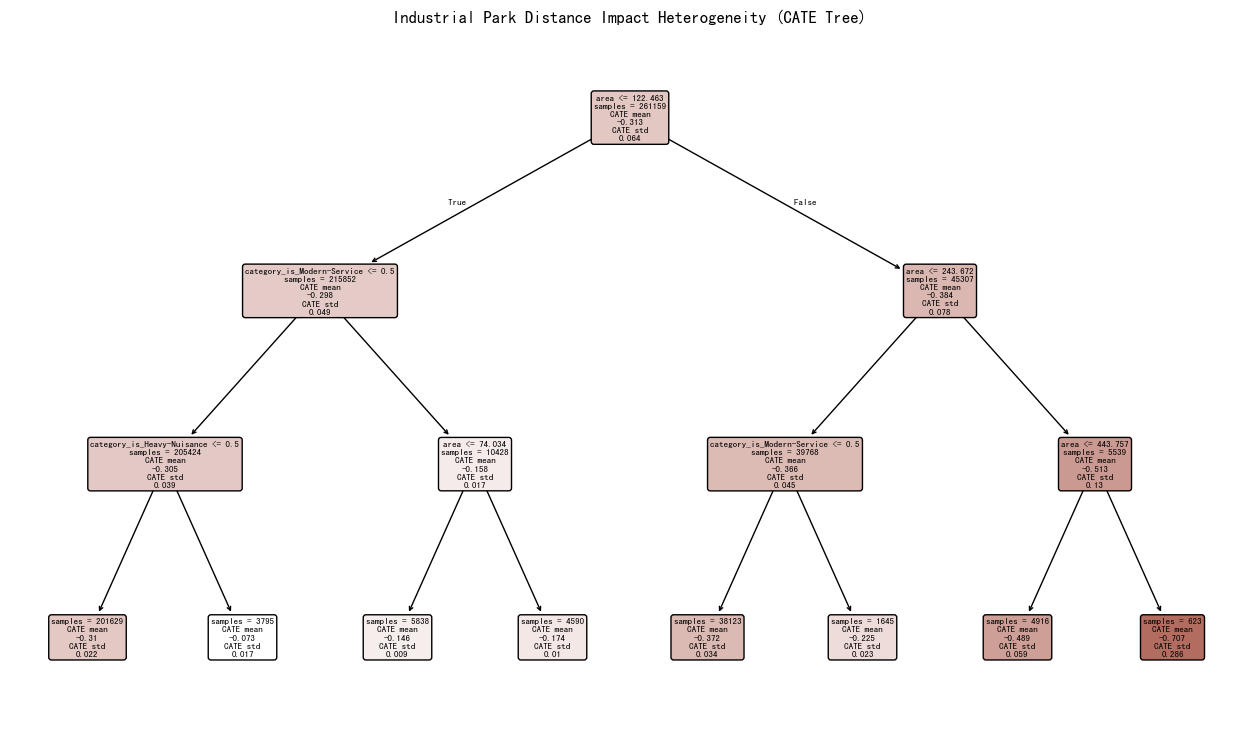

In [61]:
import warnings
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from econml.dml import LinearDML
from econml.cate_interpreter import SingleTreeCateInterpreter

warnings.filterwarnings('ignore')

est = LinearDML(
    model_y=XGBRegressor(**best_params_y),
    model_t=XGBRegressor(**best_params_t),
    discrete_treatment=False, # 距离是连续变量
    cv=5,                     # 5折交叉拟合
    random_state=42
)

est.fit(Y, T_log, X=X, W=W, inference="statsmodels")

intrp = SingleTreeCateInterpreter(max_depth=3, min_samples_leaf=100)
intrp.interpret(est, X)

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False  
plt.figure(figsize=(16, 9))
intrp.plot(feature_names=X_cols) # X_cols 是你传入 X 的特征名称列表
plt.title("Industrial Park Distance Impact Heterogeneity (CATE Tree)")
plt.show()

In [62]:
print(est.summary())

                              Coefficient Results                               
                           point_estimate stderr zstat  pvalue ci_lower ci_upper
--------------------------------------------------------------------------------
distance_to_center                   -0.0    0.0 -1.475   0.14   -0.001      0.0
category_is_Others                 -0.111  0.015 -7.191    0.0   -0.141    -0.08
category_is_High-Tech              -0.079   0.01 -7.685    0.0     -0.1   -0.059
category_is_General-Mfg            -0.118  0.019 -6.368    0.0   -0.155   -0.082
category_is_Heavy-Nuisance          0.124  0.018  7.071    0.0     0.09    0.159
category_is_Modern-Service          0.044  0.016  2.733  0.006    0.012    0.075
area                               -0.001  0.001 -1.364  0.173   -0.002      0.0
                       CATE Intercept Results                       
               point_estimate stderr zstat  pvalue ci_lower ci_upper
----------------------------------------------------